In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
dataset = pd.read_csv("deliveries.csv")
dataset.head(3)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN


In [3]:
dataset.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

In [4]:
dataset.shape

(260920, 17)

In [5]:
dataset = dataset.fillna(value=0)

In [6]:
dataset.isnull().sum()

match_id            0
inning              0
batting_team        0
bowling_team        0
over                0
ball                0
batter              0
bowler              0
non_striker         0
batsman_runs        0
extra_runs          0
total_runs          0
extras_type         0
is_wicket           0
player_dismissed    0
dismissal_kind      0
fielder             0
dtype: int64

In [7]:
dataset.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')

In [8]:
first_game = dataset.loc[(dataset.match_id == 335982)]

In [9]:
dataset = dataset.drop(columns=["batter","bowler","non_striker"])

In [10]:
first_game.head(3)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,0,0,0
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,0,0,0,0,0
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,0,0,0


In [11]:
first_game = first_game.drop(columns=["batter","bowler","non_striker"])

In [12]:
first_game.head(5)

,match_id,inning,batting_team,bowling_team,over,ball,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,0,1,1,legbyes,0,0,0,0
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,0,0,0,0,0,0,0,0
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,0,1,1,wides,0,0,0,0
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,0,0,0,0,0,0,0,0
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,0,0,0,0,0,0,0,0


In [13]:
first_game.columns

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket',
       'player_dismissed', 'dismissal_kind', 'fielder'],
      dtype='object')

In [14]:
temp = 0
full_data = []
for i in range(0,first_game.shape[0]):
    x = first_game["total_runs"][i]+ temp
    temp = x 
    full_data.append(x)

In [15]:
new = {"full_data":full_data}

In [16]:
full_data = pd.DataFrame(new)

In [17]:
first_game = pd.concat([first_game , full_data],axis=1)

In [18]:
run_check = first_game.loc[(first_game.inning) == 1]

In [19]:
check = run_check.drop_duplicates(subset=["over"])
x = check["over"]
y = check["full_data"]

In [20]:
from scipy.interpolate import make_interp_spline,BSpline

In [21]:
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(x.min(), x.max(), 300) 

Text(0.5, 1.0, 'First Game')

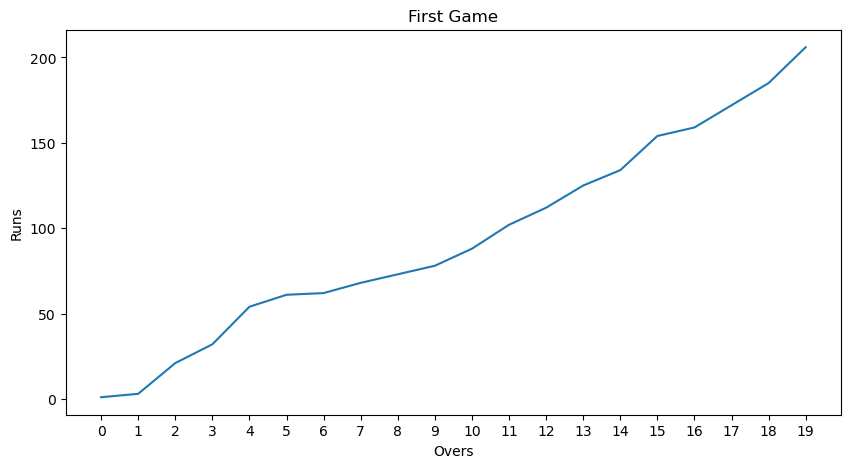

In [22]:
spl = make_interp_spline(x,y, k=3)  # type: BSpline
power_smooth = spl(xnew)


plt.figure(figsize=(10,5))
plt.plot(x,y,data=run_check)
plt.xticks(range(0,20))
plt.xlabel("Overs")
plt.ylabel("Runs")
plt.title("First Game")

<Axes: xlabel='over', ylabel='total_runs'>

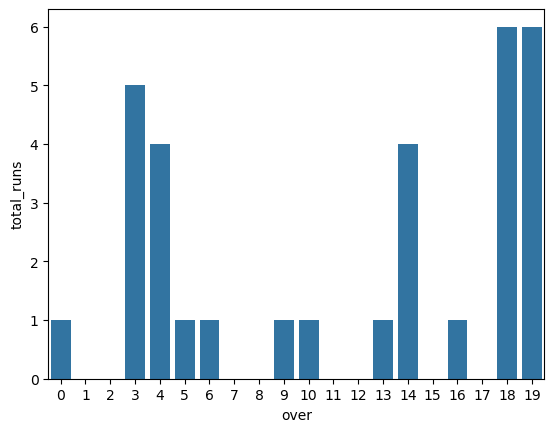

In [23]:
sns.barplot(data=check,x="over",y="total_runs")

In [24]:
run_check["total_runs"].sum()

np.int64(222)

In [25]:
dataset.head(3)

,match_id,inning,batting_team,bowling_team,over,ball,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,0,1,1,legbyes,0,0,0,0
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,0,0,0,0,0,0,0,0
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,0,1,1,wides,0,0,0,0


In [26]:
dataset = dataset.drop(columns=["ball","extras_type","player_dismissed","dismissal_kind","fielder"])

In [27]:
dataset["batting_team"].value_counts().count() , dataset["bowling_team"].value_counts().count()

(np.int64(19), np.int64(19))

In [28]:
dataset = dataset.replace(["Delhi Daredevils","Kings XI Punjab","Royal Challengers Bangalore","Rising Pune Supergiant"],
                         ["Delhi Capitals","Punjab Kings","Royal Challengers Bengaluru","Rising Pune Supergiants"])

In [29]:
dataset["batting_team"].value_counts()

batting_team
Mumbai Indians                 31437
Royal Challengers Bengaluru    30023
Delhi Capitals                 29732
Kolkata Knight Riders          29514
Punjab Kings                   29479
Chennai Super Kings            28651
Rajasthan Royals               26242
Sunrisers Hyderabad            21843
Deccan Chargers                 9034
Gujarat Titans                  5494
Pune Warriors                   5443
Lucknow Super Giants            5400
Gujarat Lions                   3566
Rising Pune Supergiants         3480
Kochi Tuskers Kerala            1582
Name: count, dtype: int64

In [30]:
dataset["batting_team"].value_counts().count() , dataset["bowling_team"].value_counts().count()

(np.int64(15), np.int64(15))

In [31]:
dataset["match_id"].value_counts().count()

np.int64(1095)

In [32]:
dataset["batting_team"]

0         Kolkata Knight Riders
1         Kolkata Knight Riders
2         Kolkata Knight Riders
3         Kolkata Knight Riders
4         Kolkata Knight Riders
                  ...          
260915    Kolkata Knight Riders
260916    Kolkata Knight Riders
260917    Kolkata Knight Riders
260918    Kolkata Knight Riders
260919    Kolkata Knight Riders
Name: batting_team, Length: 260920, dtype: object

In [33]:
dataset.head(3)

,match_id,inning,batting_team,bowling_team,over,batsman_runs,extra_runs,total_runs,is_wicket
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,0,1,1,0
1,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,0,0,0,0
2,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,0,0,1,1,0


In [34]:
dataset.shape

(260920, 9)

In [35]:
runs1 = []
runs2 = []
wicketfirst = []
wicketsecond = []
battingteam = []
bowlingteam = []

In [36]:
dataset.iloc[0]

match_id                             335982
inning                                    1
batting_team          Kolkata Knight Riders
bowling_team    Royal Challengers Bengaluru
over                                      0
batsman_runs                              0
extra_runs                                1
total_runs                                1
is_wicket                                 0
Name: 0, dtype: object

In [37]:
matchid = dataset.iloc[0,0]
inning_one_team_run = 0
inning_two_team_run = 0
wicket1 = 0
wicket2 = 0
team1 = 0
team2 = 0

for i in range(0 , dataset.shape[0]):
    if (dataset.iloc[i,0] == matchid):
        team1 = dataset.iloc[i,2]
        team2 = dataset.iloc[i,3]
        if(dataset.iloc[i,1] == 1):
            inning_one_team_run += dataset.iloc[i,7]
            wicket1 += dataset.iloc[i,8]
        else:
            inning_two_team_run += dataset.iloc[i,7]
            wicket2 += dataset.iloc[i,8]
            
    else:
        matchid = dataset.iloc[i,0]
        runs1.append(inning_one_team_run)
        wicketfirst.append(wicket1)
        inning_one_team_run = 0
        wicket1 = 0
        
        runs2.append(inning_two_team_run)
        wicketsecond.append(wicket2)
        inning_two_team_run = 0
        wicket2 = 0

        battingteam.append(team1)
        bowlingteam.append(team2)
        
        team1 = dataset.iloc[i,2]
        team2 = dataset.iloc[i,3]
        
        if(dataset.iloc[i,1] == 1):
            inning_one_team_run += dataset.iloc[i,7]
            wicket1 += dataset.iloc[i,8]
        else:
            inning_two_team_run += dataset.iloc[i,7]
            wicket2 += dataset.iloc[i,8]
            

wicketsecond.append(wicket2)
wicketfirst.append(wicket1)
runs2.append(inning_two_team_run)           
runs1.append(inning_one_team_run)
battingteam.append(team1)
bowlingteam.append(team2)

In [38]:
len(runs1) , len(runs2) , len(wicketfirst) , len(wicketsecond) , len(battingteam) , len(bowlingteam)

(1095, 1095, 1095, 1095, 1095, 1095)

In [39]:
new_dataset = pd.DataFrame({"First_Inning_Run":runs1,
                           "Second_Inning_Run":runs2,
                           "First_Inning_Wicket":wicketfirst,
                           "Second_Inning_Wicket":wicketsecond,
                           "Batting_Team":battingteam,
                           "Bowling_Team":bowlingteam})

In [40]:
new_dataset.head(5)

,First_Inning_Run,Second_Inning_Run,First_Inning_Wicket,Second_Inning_Wicket,Batting_Team,Bowling_Team
0,222,82,3,10,Royal Challengers Bengaluru,Kolkata Knight Riders
1,240,207,5,4,Punjab Kings,Chennai Super Kings
2,129,132,8,1,Delhi Capitals,Rajasthan Royals
3,165,166,7,5,Royal Challengers Bengaluru,Mumbai Indians
4,110,112,10,5,Kolkata Knight Riders,Deccan Chargers


In [41]:
matches_extra = pd.read_csv("matches.csv")[["toss_decision"]]
new_dataset["toss_decision"] = matches_extra["toss_decision"].values

In [42]:
new_dataset["First_Inning_RunRate"] = new_dataset["First_Inning_Run"] / 20

In [43]:
new_dataset["Toss_Winner_Batted"] = (new_dataset["toss_decision"] == "bat").astype(int)

In [44]:
the_list = []
for i in range(0, new_dataset.shape[0]):
    if(new_dataset.iloc[i,0] > new_dataset.iloc[i,1]):
        the_list.append(1)
    else:
        the_list.append(0)

thelist = pd.DataFrame({"GAME":the_list})
new_dataset = pd.concat([new_dataset, thelist], axis=1)

In [45]:
thefinaldataset = new_dataset.drop(columns=["Second_Inning_Run","Second_Inning_Wicket"])

In [46]:
thefinaldataset.head(3)

,First_Inning_Run,First_Inning_Wicket,Batting_Team,Bowling_Team,toss_decision,First_Inning_RunRate,Toss_Winner_Batted,GAME
0,222,3,Royal Challengers Bengaluru,Kolkata Knight Riders,field,11.10,0,1
1,240,5,Punjab Kings,Chennai Super Kings,bat,12.00,1,1
2,129,8,Delhi Capitals,Rajasthan Royals,bat,6.45,1,0


In [47]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier
from sklearn.model_selection import train_test_split

In [48]:
x = thefinaldataset.drop(columns=["GAME"])
y = thefinaldataset["GAME"]

In [49]:
scaling_data = ["First_Inning_Run","First_Inning_Wicket","First_Inning_RunRate"]

In [50]:
scaler_transformation = Pipeline(
    steps=[("scaler",StandardScaler())]
)

In [51]:
encoding_data_Onehot = ["Batting_Team","Bowling_Team","toss_decision"]

In [52]:
encoding_transformation_OneHot = Pipeline(
    steps=[("encoder_onehot",OneHotEncoder(handle_unknown="ignore"))]
)

In [53]:
preprocessor = ColumnTransformer(
    transformers=[("scaling_things",scaler_transformation,scaling_data),
                 ("encoding_things_Onehot",encoding_transformation_OneHot,encoding_data_Onehot)]
)

In [54]:
clf = Pipeline(
    steps=[("preprocessor", preprocessor),
           ("classifier", RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_split=5, random_state=42))]
)

In [55]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [56]:
clf.fit(x_train , y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaling_things', ...), ('encoding_things_Onehot', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [57]:
clf.score(x_test , y_test) , clf.score(x_train ,y_train)

(0.6757990867579908, 0.7408675799086758)

In [58]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(clf, x, y, cv=5)
print(scores, scores.mean())

[0.64840183 0.68949772 0.65296804 0.64383562 0.68493151] 0.6639269406392694


In [61]:
import pickle
pickle.dump(clf, open("ipl_model.pkl", "wb"))